# Multi-Agent Sales Workflow with Agentic Governance

This notebook demonstrates real-time node-level evaluation using watsonx.governance AgenticEvaluator.

## Key Features
- Node-level evaluation with decorators
- Real-time metrics during workflow execution
- Graph visualization
- Comprehensive metrics DataFrame with costs, latency, and quality scores

## Setup

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import uuid
from typing import TypedDict
from supervisory_agent import SupervisoryAgent
from contract_agent import ContractAgent
from research_agent import research_partner
from matching_agent import MatchingAgent
from action_agent import ActionAgent

load_dotenv()

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Initialize watsonx.governance

In [2]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.config import AgenticAIConfiguration
from ibm_watsonx_gov.config.agentic_ai_configuration import TracingConfiguration
from ibm_watsonx_gov.metrics import FaithfulnessMetric, ContextRelevanceMetric
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel
from ibm_watsonx_gov.entities.llm_judge import LLMJudge

PROJECT_ID = os.getenv("WATSONX_PROJECT_ID")
REGION = "us-south"

# Initialize LLM Judge
llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-3-70b-instruct",
        project_id=PROJECT_ID,
        region=REGION
    )
)

# Initialize Agentic Evaluator
evaluator = AgenticEvaluator(
    tracing_configuration=TracingConfiguration(project_id=PROJECT_ID)
)

print("[SUCCESS] watsonx.governance initialized")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/ibm_watsonx_gov/tools/utils/environment.py:55: UserWarning: Since WATSONX_REGION is not provided in the environment variable, the Dallas region will be used as the default.
  warnings.warn(


Custom exporter logging initialized. App name: Mac_ipykernel_launcher
Traceloop exporting traces to a custom exporter

Metrics are disabled
[SUCCESS] watsonx.governance initialized


## Initialize LLM

In [3]:
# Set WATSONX_APIKEY in environment if not already set
if 'WATSONX_APIKEY' not in os.environ:
    os.environ['WATSONX_APIKEY'] = os.getenv('WATSONX_APIKEY', '')

print(f"API Key set: {'Yes' if os.environ.get('WATSONX_APIKEY') else 'No'}")
print(f"Project ID: {PROJECT_ID[:8]}..." if PROJECT_ID else "Project ID not set")

API Key set: Yes
Project ID: ce21bf42...


In [4]:
from langchain_ibm import ChatWatsonx

# Initialize ChatWatsonx (uses WATSONX_APIKEY from environment)
parameters = {
    "temperature": 0.3,
    "max_tokens": 500,
}

chat_model = ChatWatsonx(
    model_id="meta-llama/llama-4-maverick-17b-128e-instruct-fp8",
    url="https://us-south.ml.cloud.ibm.com",
    project_id=PROJECT_ID,
    params=parameters,
)

print("[SUCCESS] LLM initialized")

[SUCCESS] LLM initialized


## Initialize Agents

In [5]:
# Initialize the Supervisory Agent
print("Initializing Supervisory Agent...")
supervisor = SupervisoryAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Supervisory Agent ready\n")

# Initialize Contract Agent
print("Initializing Contract Agent...")
contract_agent = ContractAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Contract Agent ready\n")

# Note: Research functionality uses research_partner function directly
print("✓ Research function imported\n")

# Initialize Matching Agent
print("Initializing Matching Agent...")
matching_agent = MatchingAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Matching Agent ready\n")

# Initialize Action Agent
print("Initializing Action Agent...")
action_agent = ActionAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Action Agent ready\n")

Initializing Supervisory Agent...
✓ Supervisory Agent ready

Initializing Contract Agent...
✓ Contract Agent ready

✓ Research function imported

Initializing Matching Agent...
✓ Matching Agent ready

Initializing Action Agent...
✓ Action Agent ready



## Define State

In [6]:
class SalesAgentState(TypedDict):
    input_text: str  # User query
    partner_name: str  # Partner name extracted by supervisor
    workflow_type: str  # Workflow type from supervisor
    contract_context: list[str]  # Context from contracts
    research_context: list[str]  # Context from research
    matching_results: dict  # Matching results
    action_plan: dict  # Action plan and recommendations
    generated_text: str  # Final output
    message_id: str  # Unique tracking ID
    record_id: str  # Record ID for governance

## Define Workflow Nodes with Governance Decorators

In [7]:
from langgraph.config import RunnableConfig
from langchain_core.prompts import ChatPromptTemplate

# Node 0: Supervisory Agent - Analyze query and determine workflow
def supervisory_node(state: SalesAgentState, config: RunnableConfig) -> dict:
    """Analyze query and extract partner name and workflow type"""
    query = state["input_text"]
    
    # Use supervisor to analyze the query
    result = supervisor.run(query)
    
    return {
        "partner_name": result.get("partner_name", "Unknown"),
        "workflow_type": result.get("workflow_type", "general_inquiry")
    }

# Node 1: Contract Agent - Retrieve contract information
contract_config = {
    "input_fields": ["input_text", "partner_name"],
    "context_fields": ["contract_context"],
    "message_id": "message_id"
}

@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(**contract_config),
    metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
    compute_real_time=True
)
def contract_node(state: SalesAgentState, config: RunnableConfig) -> dict:
    """Retrieve contract information using Contract Agent"""
    partner_name = state.get("partner_name", "Unknown")
    
    # Use contract agent's run_portfolio method
    portfolio_result = contract_agent.run_portfolio(partner_name)
    
    # Extract contract records from portfolio
    contracts = portfolio_result.get("contract_results", [])
    
    # Format contracts as context strings
    context = []
    for contract in contracts:
        structured = contract.get("structured_summary", {})
        amount = structured.get('amount', 0)
        # Handle amount as string or number
        if isinstance(amount, str):
            amount_str = amount
        elif isinstance(amount, (int, float)):
            amount_str = f"${amount:,.2f}"
        else:
            amount_str = "N/A"
        
        products = structured.get('products', [])
        products_str = ', '.join(products) if products else 'N/A'
        
        context.append(
            f"Contract: {contract.get('file_name', 'N/A')}, "
            f"Amount: {amount_str}, "
            f"Products: {products_str}, "
            f"End Date: {contract.get('end_date', 'N/A')}"
        )
    
    return {"contract_context": context}

# Node 2: Research Agent - Get partner research
research_config = {
    "input_fields": ["input_text", "partner_name"],
    "context_fields": ["research_context"],
    "message_id": "message_id"
}

@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(**research_config),
    metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
    compute_real_time=True
)
def research_node(state: SalesAgentState, config: RunnableConfig) -> dict:
    """Research partner information using research_partner function"""
    partner_name = state.get("partner_name", "Unknown")
    
    # Use research_partner function to get partner profile
    profile = research_partner(partner_name)
    
    # Format research as context strings
    context = [
        f"Partner: {profile.get('name', 'N/A')}",
        f"Maturity Level: {profile.get('maturity_level', 'N/A')}",
        f"Sales Velocity: {profile.get('sales_velocity', 'N/A')}",
        f"CRM Opportunities: {len(profile.get('crm_opportunities', []))}"
    ]
    
    return {"research_context": context}

# Node 3: Matching Agent - Match contracts to CRM
def matching_node(state: SalesAgentState, config: RunnableConfig) -> dict:
    """Match contracts to CRM opportunities using Matching Agent"""
    partner_name = state.get("partner_name", "Unknown")
    
    # Get portfolio from contract agent
    portfolio_result = contract_agent.run_portfolio(partner_name)
    
    # Get CRM opportunities from research context
    research_profile = research_partner(partner_name)
    crm_opportunities = research_profile.get("internal_data", {}).get("sales_history", {}).get("opportunities", [])
    
    # Use matching agent's run method
    matching_results = matching_agent.run(portfolio_result, crm_opportunities)
    
    return {"matching_results": matching_results}

# Node 4: Action Agent - Generate action plan
action_config = {
    "input_fields": ["input_text", "partner_name"],
    "context_fields": ["contract_context", "research_context"],
    "output_fields": ["generated_text"]
}

@evaluator.evaluate_faithfulness(
    configuration=AgenticAIConfiguration(**action_config),
    metrics=[FaithfulnessMetric(llm_judge=llm_judge)],
    compute_real_time=True
)
def action_node(state: SalesAgentState, config: RunnableConfig) -> dict:
    """Generate action plan using Action Agent"""
    partner_name = state.get("partner_name", "Unknown")
    query = state.get("input_text", "")
    
    # Get portfolio and research data
    portfolio_result = contract_agent.run_portfolio(partner_name)
    research_profile = research_partner(partner_name)
    matching_results = state.get("matching_results", {})
    
    # Use action agent's run method
    action_result = action_agent.run(
        contract_summary=portfolio_result,
        partner_profile=research_profile,
        seller_query=query,
        matching_data=matching_results
    )
    
    # Extract generated text from action result
    generated_text = action_result.get("final_output", "No action plan generated")
    
    return {
        "action_plan": action_result,
        "generated_text": generated_text
    }

print("[SUCCESS] Workflow nodes defined with governance decorators")

[SUCCESS] Workflow nodes defined with governance decorators


## Build LangGraph Workflow

In [8]:
from langgraph.graph import START, END, StateGraph

# Build the graph
builder = StateGraph(SalesAgentState)

# Add nodes
builder.add_node("supervisor", supervisory_node)
builder.add_node("contracts", contract_node)
builder.add_node("research", research_node)
builder.add_node("matching", matching_node)
builder.add_node("action", action_node)

# Add edges - Multi-agent workflow
builder.add_edge(START, "supervisor")
builder.add_edge("supervisor", "contracts")
builder.add_edge("contracts", "research")
builder.add_edge("research", "matching")
builder.add_edge("matching", "action")
builder.add_edge("action", END)

# Compile
sales_agent = builder.compile()

print("[SUCCESS] Multi-agent LangGraph workflow compiled")

[SUCCESS] Multi-agent LangGraph workflow compiled


## Visualize Workflow Graph

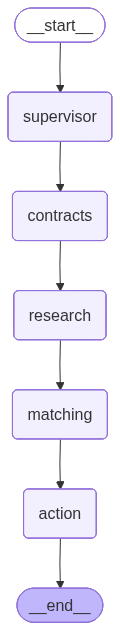

In [9]:
from IPython.display import Image, display

display(Image(sales_agent.get_graph(xray=True).draw_mermaid_png()))

## Execute Workflow with Governance Evaluation

In [10]:
# Single test query
test_query = "I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps"

print("="*80)
print("EXECUTING WORKFLOW WITH GOVERNANCE")
print("="*80)
print(f"\nQuery: {test_query}\n")

# Execute with governance tracking
evaluator.start_run()

try:
    result = sales_agent.invoke({
        "input_text": test_query,
        "message_id": "test_001",
        "record_id": "test_001",
        "partner_name": "",
        "workflow_type": "",
        "contract_context": [],
        "research_context": [],
        "matching_results": {},
        "action_plan": {},
        "generated_text": ""
    })
finally:
    evaluator.end_run()

# Get metrics
eval_result = evaluator.get_result()
metrics_df = eval_result.to_df()

# Display generated response
print("\n" + "="*80)
print("GENERATED RESPONSE")
print("="*80)
print(result['generated_text'])

# Display metrics table
print("\n" + "="*80)
print("GOVERNANCE METRICS")
print("="*80)
display(metrics_df)

# Display metrics summary
print("\n" + "="*80)
print("METRICS SUMMARY")
print("="*80)

# Faithfulness scores
faithfulness_cols = [col for col in metrics_df.columns if 'faithfulness' in col.lower()]
if faithfulness_cols:
    print("\nFaithfulness Scores:")
    for col in faithfulness_cols:
        if pd.api.types.is_numeric_dtype(metrics_df[col]):
            score = metrics_df[col].iloc[0]
            print(f"  {col}: {score:.3f}")

# Context relevance scores
relevance_cols = [col for col in metrics_df.columns if 'context_relevance' in col.lower() or 'retrieval' in col.lower()]
if relevance_cols:
    print("\nContext Relevance Scores:")
    for col in relevance_cols:
        if pd.api.types.is_numeric_dtype(metrics_df[col]):
            score = metrics_df[col].iloc[0]
            print(f"  {col}: {score:.3f}")

# Latency
latency_cols = [col for col in metrics_df.columns if 'latency' in col.lower()]
if latency_cols:
    print("\nLatency (seconds):")
    for col in latency_cols:
        if pd.api.types.is_numeric_dtype(metrics_df[col]):
            latency = metrics_df[col].iloc[0]
            print(f"  {col}: {latency:.3f}s")

# Cost
cost_cols = [col for col in metrics_df.columns if 'cost' in col.lower()]
if cost_cols:
    print("\nCost:")
    total_cost = metrics_df[cost_cols].sum().sum()
    print(f"  Total: ${total_cost:.4f}")

print("\n" + "="*80)
print("[SUCCESS] Workflow completed with governance metrics")
print("="*80)


EXECUTING WORKFLOW WITH GOVERNANCE

Query: I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps


SUPERVISORY AGENT - Workflow Initialization
Seller Query: I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps

Workflow Type: renewal_expiration_awareness
Required Agents: contract, action
Partner Name: Confluent

EXECUTING CONTRACT AGENT
Preloading contract portfolio for partner: Confluent
Contract scope: all files in docs/ beginning with Confluent_IBM
✓ Using cached data for: Confluent_IBM-1.30.2024.docx
✓ Using cached metadata for: Confluent_

,message_id,action.latency,contracts.latency,matching.latency,message.cost,message.duration,message.input_token_count,message.output_token_count,research.latency,supervisor.latency
0,5ba91faf7a024204f7c1bd874da5e709,46.6197,26.0407,178.8697,0.0242,604.3728,27330.0,6805.0,19.0651,333.7305



METRICS SUMMARY

Latency (seconds):
  action.latency: 46.620s
  contracts.latency: 26.041s
  matching.latency: 178.870s
  research.latency: 19.065s
  supervisor.latency: 333.731s

Cost:
  Total: $0.0242

[SUCCESS] Workflow completed with governance metrics


## Export Results

In [12]:
# Export metrics to CSV
output_file = "sales_agent_governance_results.csv"
metrics_df.to_csv(output_file, index=False)
print(f"[SUCCESS] Metrics exported to {output_file}")

[SUCCESS] Metrics exported to sales_agent_governance_results.csv


## Summary

This notebook demonstrates:
1. **Real-time node-level evaluation** using AgenticEvaluator decorators
2. **LangGraph workflow** with contract and CRM retrieval nodes
3. **Graph visualization** showing the workflow structure
4. **Comprehensive metrics** including faithfulness, context relevance, costs, and latency
5. **Batch processing** with governance tracking for multiple queries

### Key Differences from Batch Evaluation:
- Metrics are computed **during** workflow execution, not after
- Each node can be evaluated independently
- Provides detailed insights into each step of the workflow
- Enables conditional routing based on metric scores